In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [16]:
df= pd.read_csv(r"C:\Users\pc\OneDrive\Desktop\ecommerce-sales-analytics\data\processed\clean_superstore.csv")
print("data succesfully loaded")
print("shape:",df.shape)
print(df.head())

data succesfully loaded
shape: (9994, 24)
   row_id        order_id  order_date   ship_date       ship_mode customer_id  \
0       1  CA-2016-152156  2016-11-08  2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156  2016-11-08  2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688  2016-06-12  2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966  2015-10-11  2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966  2015-10-11  2015-10-18  Standard Class    SO-20335   

     customer_name    segment        country             city  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

          category  sub-category  \
0        Furni

In [29]:
#Business KPIS
total_profit= df['profit'].sum()
total_revenue= df['sales'].sum()
total_orders= df['order_id'].nunique()
profit_margin= (total_profit/ total_revenue)*100
print(f"total_profit:${total_profit:,.2f}")
print(f"total_revenue:${total_revenue:,.2f}")
print(f"total_orders:{total_orders}")
print(f"profit_margin:${profit_margin:,.2f}")

total_profit:$286,401.82
total_revenue:$2,297,200.86
total_orders:5009
profit_margin:$12.47


   year        sales
0  2014  484247.4981
1  2015  470532.5090
2  2016  609205.5980
3  2017  733215.2552


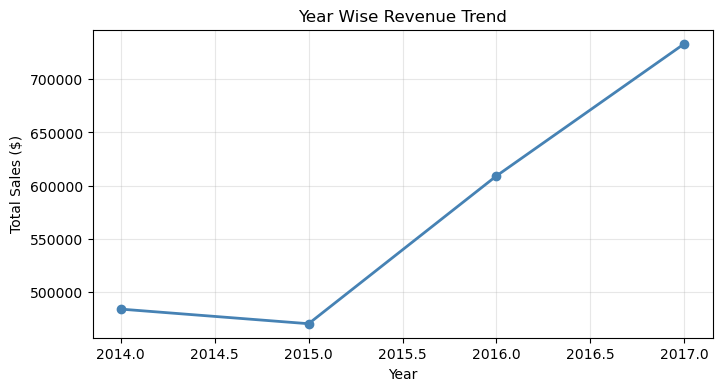

In [55]:
#yearly revenue trend
yearly_sales= df.groupby('year')['sales'].sum().reset_index()
print(yearly_sales)
plt.figure(figsize=(8,4))
plt.plot(yearly_sales['year'],yearly_sales['sales'],
marker='o',
color='steelblue',
linewidth=2)

plt.title("Year Wise Revenue Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales ($)")
plt.grid(True,alpha=0.3)
plt.show()


    month        sales
0       1   94924.8356
1       2   59751.2514
2       3  205005.4888
3       4  137762.1286
4       5  155028.8117
5       6  152718.6793
6       7  147238.0970
7       8  159044.0630
8       9  307649.9457
9      10  200322.9847
10     11  352461.0710
11     12  325293.5035


<BarContainer object of 12 artists>

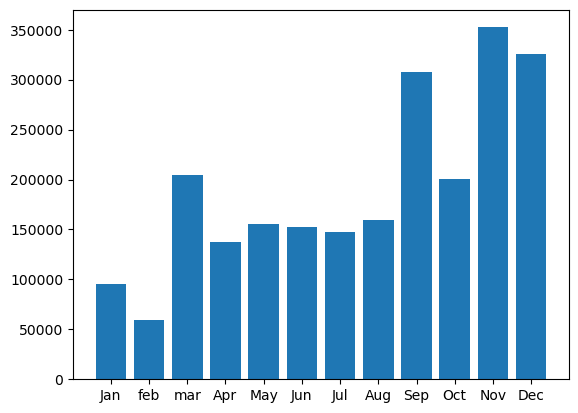

In [74]:
#monthly revenue
monthly_sales= df.groupby('month')['sales'].sum().reset_index()
print(monthly_sales)
monthly_names={1:'Jan',2:'feb',3:'mar',4:'Apr',
               5:'May', 6:'Jun', 7:'Jul', 8:'Aug',
               9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
monthly_sales['monthly_name']= monthly_sales['month'].map(monthly_names)
plt.bar(monthly_sales['monthly_name'],monthly_sales['sales'])

In [76]:
#category performance
category_stats=df.groupby('category').agg({
    'profit': 'sum',
    'sales': 'sum'}).reset_index()
print(category_stats)

          category       profit        sales
0        Furniture   18451.6528  741999.7953
1  Office Supplies  122495.0308  719047.0320
2       Technology  145455.1381  836154.0330


                                        product_name      sales
0              Canon imageCLASS 2200 Advanced Copier  61599.824
1  Fellowes PB500 Electric Punch Plastic Comb Bin...  27453.384
2  Cisco TelePresence System EX90 Videoconferenci...  22638.480
3       HON 5400 Series Task Chairs for Big and Tall  21870.576
4         GBC DocuBind TL300 Electric Binding System  19823.479
5   GBC Ibimaster 500 Manual ProClick Binding System  19024.500
6               Hewlett Packard LaserJet 3310 Copier  18839.686
7  HP Designjet T520 Inkjet Large Format Printer ...  18374.895
8          GBC DocuBind P400 Electric Binding System  17965.068
9        High Speed Automatic Electric Letter Opener  17030.312


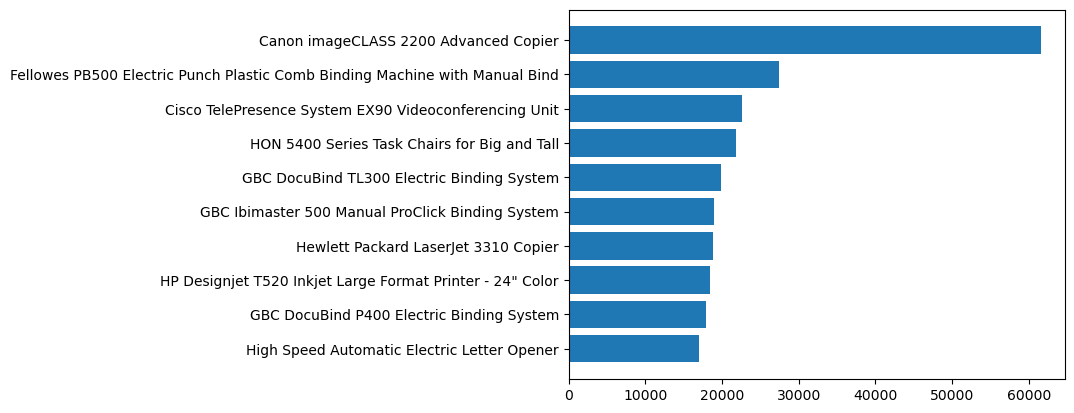

In [88]:
# Top 10 Products
top_product= df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10).reset_index()
print(top_product)
plt.barh(top_product['product_name'], top_product['sales'])
plt.gca().invert_yaxis()

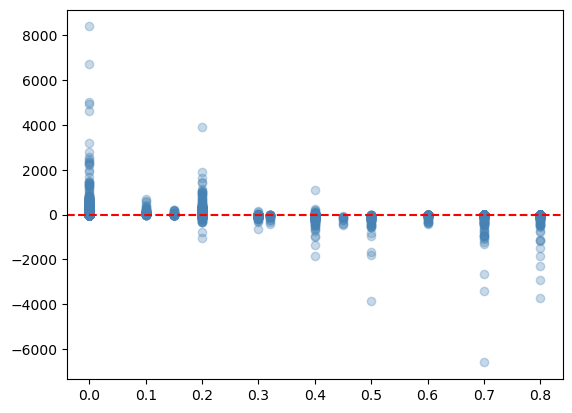

In [94]:
# Discount vs Profit
plt.scatter(df['discount'],df['profit'],
            alpha=0.3,
            color='steelblue')
plt.axhline(y=0,color='red',linestyle='--')
           

In [97]:
segment_stats = df.groupby('segment').agg({
    'sales'   : 'sum',
    'profit'  : 'sum',
    'order_id': 'nunique'
}).reset_index()

segment_stats.columns = ['segment', 'total_sales', 'total_profit', 'total_orders']

print(segment_stats)

       segment   total_sales  total_profit  total_orders
0     Consumer  1.161401e+06   134122.4792          2586
1    Corporate  7.061464e+05    91979.9040          1514
2  Home Office  4.296531e+05    60299.4385           909


([<matplotlib.patches.Wedge at 0x1f409a5ecf0>,
 [Text(-0.019255799354537615, 1.099831448082486, 'Consumer'),
  Text(-0.5936664965175892, -0.9260454043471797, 'Corporate'),
  Text(0.9155113397403079, -0.6097860172280986, 'Home Office')],
 [Text(-0.010503163284293245, 0.5999080625904468, '50.6%'),
  Text(-0.323818089009594, -0.5051156750984616, '30.7%'),
  Text(0.4993698216765315, -0.33261055485169005, '18.7%')])

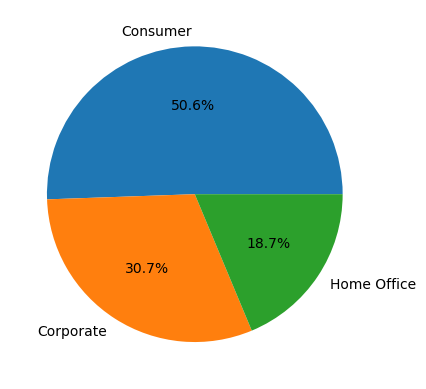

In [98]:
# Segment analysis
plt.pie(segment_stats['total_sales'],
        labels=segment_stats['segment'],
        autopct='%1.1f%%')
        

In [102]:
print(f"Top Category : {df.groupby('category')['sales'].sum().idxmax()}")
print(f" top Region   : {df.groupby('region')['sales'].sum().idxmax()}")
print(f" Best Month   : {df.groupby('month')['sales'].sum().idxmax()}")

Top Category : Technology
 top Region   : West
 Best Month   : 11
